רגרסיה ליניארית - חיזוי מספר רציף עם קשר ליניארי - לדוגמה חיזוי משכורת לפני שנות נסיון

עץ רנדומי - חיזוי מספר רציף עם קשרים מורכבים - לדוגמה חיזוי כמות כרטיסים עם הפרמטרים שלנו

נתונים חשובים שרואים בסוף הדף -

Measurement for Test data:
1. MAE:  8.493897833770063
2. RMSE:  13.946797062693589
3. R²:  0.5738049089183384

בממוצע, החיזוי של המודל סוטה מהמספר האמיתי ב-~8.5 כרטיסים.

רוב התחזיות שלנו טובות (~8 כרטיסים סטייה), אבל יש מיעוט של תחזיות גרועות מאוד


המודל שלנו מסביר 57.4% מהשונות במכירות הכרטיסים. כלומר, 57.4% מהסיבות לכך שהקרנה מוכרת הרבה או מעט - המודל מבין אותן. ה-42.6% הנותרים הם דברים שהמודל לא יודע: מזג אוויר, שיווק, ביקורות, אירועים מתחרים וכו'.


# Decision Tree Example - HotCinema Prediction



In [2]:
import pandas as pd # Import pandas library for table management
import numpy as np #math, statistics and others in python
import matplotlib. pyplot as plt #used for visualizations
from sklearn.model_selection import train_test_split #to split the dataset for training and testing
from sklearn.tree import DecisionTreeClassifier # import Decision Tree Classifier model
# Include confusion matrix plot function to be used when we have defined a classifir (model) as we have (model with KNN)
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score
import warnings # current version of seaborn generates a bunch of warnings that we'll ignore
warnings.filterwarnings("ignore")

## Read HotCinema Data

In [3]:
# read dataset from xlsx
HotCinemaData = pd.read_excel("/content/HotCinemaData_Cleaned_Added.xlsx")

## Analyse HotCinema Data

In [4]:
# Check the fields, types and no-nulls
HotCinemaData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237947 entries, 0 to 237946
Data columns (total 87 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   row_id_int               237947 non-null  int64  
 1   Movie_string             237947 non-null  object 
 2   Origial Name_string      237947 non-null  object 
 3   OMDbTitle_string         237947 non-null  object 
 4   Venue Capacity_int       237947 non-null  int64  
 5   Weekday_int              237947 non-null  int64  
 6   Is_Weekend_binary        237947 non-null  int64  
 7   MovieWeek_int            237947 non-null  int64  
 8   SubtitledLanguageId_int  237947 non-null  int64  
 9   LengthInMinutes_int      237947 non-null  int64  
 10  IsDubbed_binary          237947 non-null  int64  
 11  IsSubtitled_binary       237947 non-null  int64  
 12  OMDbMetascore_float      154029 non-null  float64
 13  OMDbImdbRating_float     180859 non-null  float64
 14  OMDb

In [5]:
# Take a look on the data.
HotCinemaData.head(5)

,row_id_int,Movie_string,Origial Name_string,OMDbTitle_string,Venue Capacity_int,Weekday_int,Is_Weekend_binary,MovieWeek_int,SubtitledLanguageId_int,LengthInMinutes_int,...,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Tickets Sold_int
0,0,בוזגלוס: הקרב על הירושה,Buzaglos,Buzaglos,72,7,1,7,972,89,...,0,0,0,0,0,0,0,1,0,7
1,1,לזמן את הרוע: הפרק האחרון,The Conjuring: Last Rites,The Conjuring: Last Rites,87,7,1,9,972,135,...,0,0,0,0,0,0,0,1,0,16
2,2,כלב טוב,Good Boy,Good Boy,95,7,1,1,972,85,...,0,0,0,0,0,0,0,1,0,8
3,3,להתחרט עליך,Regretting You,Regretting You,89,7,1,2,972,117,...,0,0,0,0,0,0,0,1,0,12
4,4,בלאק-פון 2,Black Phone 2,Black Phone 2,71,7,1,3,972,114,...,0,0,0,0,0,0,0,1,0,2


In [6]:
# no-null entries
HotCinemaData.isnull().sum()

,0
row_id_int,0
Movie_string,0
Origial Name_string,0
OMDbTitle_string,0
Venue Capacity_int,0
...,...
Month_9,0
Month_10,0
Month_11,0
Month_12,0


## Prepare HotCinema Data

In [7]:
# Split data  into train and test
# the parameter test_size=0.3 splits the data into 70% and 30% ratio. train=70% and test=30%
train, test = train_test_split(HotCinemaData, test_size = 0.3, random_state = 0,)
print(train.shape)
print(test.shape)

(166562, 87)
(71385, 87)


In [8]:
train.columns

Index(['row_id_int', 'Movie_string', 'Origial Name_string', 'OMDbTitle_string',
       'Venue Capacity_int', 'Weekday_int', 'Is_Weekend_binary',
       'MovieWeek_int', 'SubtitledLanguageId_int', 'LengthInMinutes_int',
       'IsDubbed_binary', 'IsSubtitled_binary', 'OMDbMetascore_float',
       'OMDbImdbRating_float', 'OMDbImdbVotes_float', 'OMDbBoxOffice_float',
       'Num_Wins_int', 'Num_Nominations_int', 'Hour_int',
       'Is_Hebrew_Local_binary', 'Has_Imdb_Data_binary', 'Genre_Action',
       'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy',
       'Genre_Crime', 'Genre_Documentary', 'Genre_Drama', 'Genre_Family',
       'Genre_Fantasy', 'Genre_History', 'Genre_Horror', 'Genre_Kids',
       'Genre_Live_Shows', 'Genre_Music', 'Genre_Musical', 'Genre_Mystery',
       'Genre_Romance', 'Genre_Sci_Fi', 'Genre_Short', 'Genre_Sport',
       'Genre_Thriller', 'Genre_War', 'Genre_Western', 'Cinema_Ashdod',
       'Cinema_Ashkelon', 'Cinema_Carmiel', 'Cinema_Haifa',

In [9]:
#רשימת העמודות שלא נכנסות למודל - 4 עמודות מזהים + ה-מטרה ובנוסף גודל האולם
cols_to_drop = ['row_id_int', 'Movie_string', 'Origial Name_string',
                'OMDbTitle_string', 'Tickets Sold_int','Venue Capacity_int']

# פיצ'רים = כל העמודות חוץ מהרשימה הזו
train_X = train.drop(columns=cols_to_drop)   # פיצ'רים לאימון
train_y = train['Tickets Sold_int']          # target לאימון

test_X = test.drop(columns=cols_to_drop)     # פיצ'רים לבדיקה
test_y = test['Tickets Sold_int']            # target לבדיקה

In [10]:
print('train_X shape:', train_X.shape)   # אמור להיות (כ-166k, 82)
print('train_y shape:', train_y.shape)   # אמור להיות (כ-166k,)
print('test_X shape:', test_X.shape)     # אמור להיות (כ-71k, 82)
print('test_y shape:', test_y.shape)     # אמור להיות (כ-71k,)

train_X shape: (166562, 81)
train_y shape: (166562,)
test_X shape: (71385, 81)
test_y shape: (71385,)


# RANDOM FOREST

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:

clf_rf = RandomForestRegressor(max_depth=30, n_estimators=200, n_jobs=-1, random_state=42)
#max_depth - max depth of trees. how much stages each tree has. 30 means that it asks 30 questions in each tree to go down.
#n_estimators - decide how much decision trees it builds. here we have 200 trees.
#n_jobs - processing power of computer, how many cores will be used to build the trees. 1 means that all of the cores are working at the same time and it shortens the running time.
#random_state - choose sub groups of data randomly for each tree. a steady number (42) makes sure that each run is the same amount of randomness.

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import joblib

# מודל קומפקטי - יותר מהיר, יותר קטן, ולרוב יותר מדויק
clf_rf = RandomForestRegressor(
    max_depth=15,        # במקום 30 - מונע overfitting
    n_estimators=100,    # במקום 200 - 100 עצים מספיקים
    min_samples_leaf=5,  # תוספת רגולריזציה
    n_jobs=-1,
    random_state=42
)
clf_rf.fit(train_X, train_y)

# בדיקת ביצועים
preds = clf_rf.predict(test_X)
print(f"MAE:  {mean_absolute_error(test_y, preds):.3f}")
print(f"RMSE: {np.sqrt(((test_y - preds)**2).mean()):.3f}")
print(f"R²:   {1 - ((test_y - preds)**2).sum() / ((test_y - test_y.mean())**2).sum():.4f}")

# שמירה
# Changed save path to local /content/ directory as Google Drive was not mounted.
joblib.dump(clf_rf, '/content/model_rf_small.pkl')
import os
size_mb = os.path.getsize('/content/model_rf_small.pkl') / (1024*1024)
print(f"\nגודל מודל: {size_mb:.1f} MB")

MAE:  9.391
RMSE: 15.692
R²:   0.4605

גודל מודל: 64.4 MB


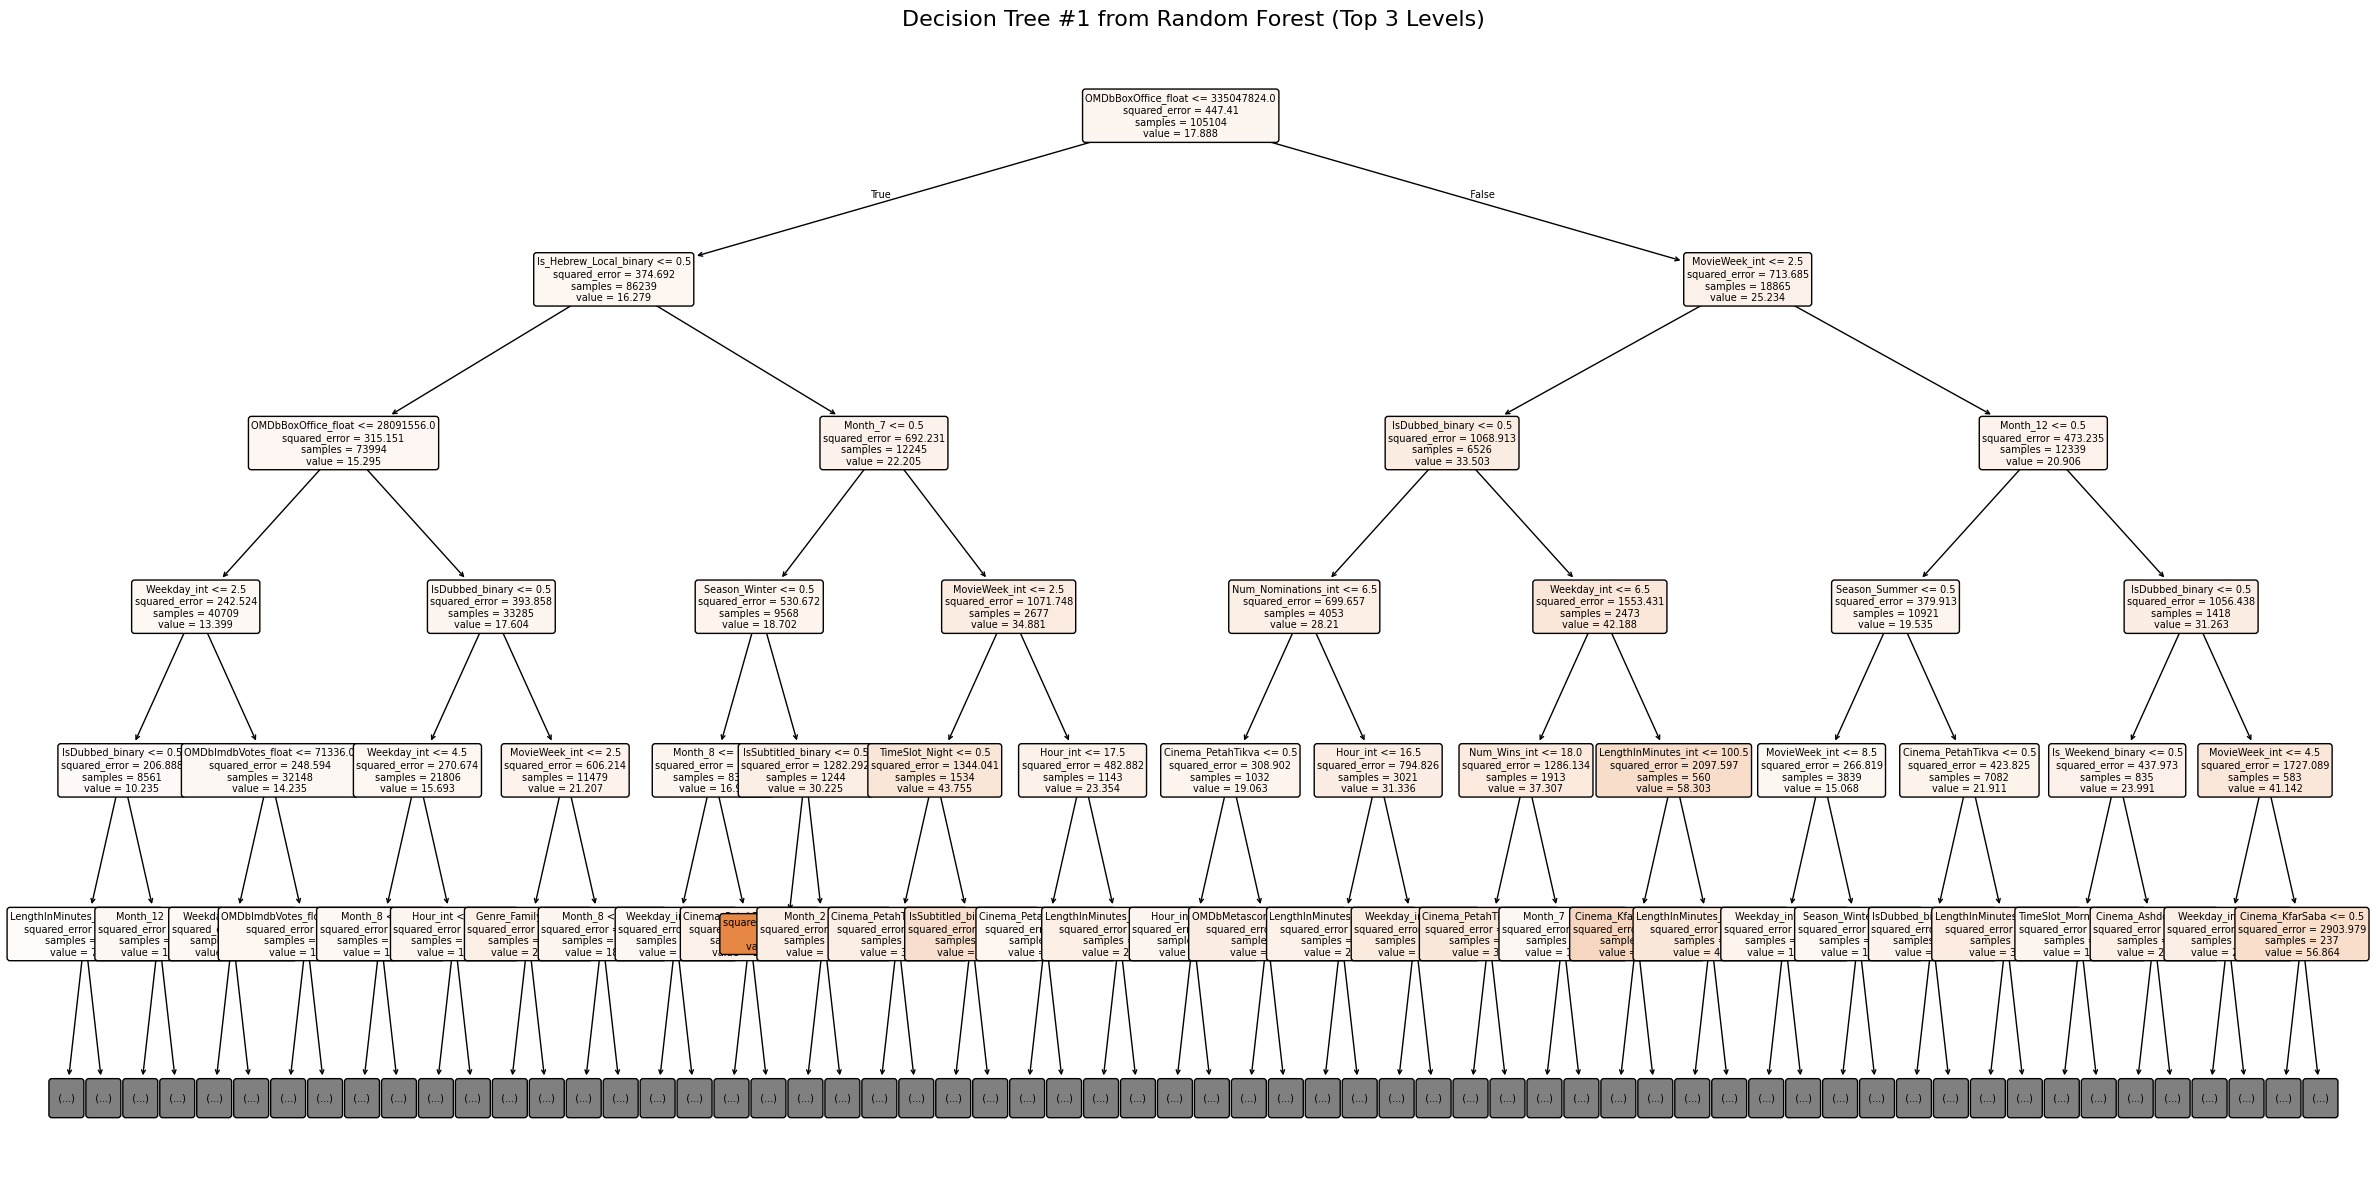

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# היער שלך מכיל 200 עצים - בוחרים אחד מהם להצגה (נניח הראשון)
single_tree = clf_rf.estimators_[0]

# העצים אצלנו עם max_depth=30 - לא ניתן להציג אותם בשלמותם (יהיה בלתי קריא)
# נציג רק את 3 השכבות העליונות
plt.figure(figsize=(24, 12))
plot_tree(
    single_tree,
    max_depth=5,                      # רק 5 שכבות עליונות
    feature_names=train_X.columns,    # שמות הפיצ'רים
    filled=True,                      # צביעה לפי הערך החזוי
    rounded=True,                     # פינות מעוגלות
    fontsize=7
)
plt.title('Decision Tree #1 from Random Forest (Top 3 Levels)', fontsize=16)
plt.tight_layout()
plt.show()

מקטע קוד שמוריד את המודל למסמך פייתון כדי להעביר אותו לקוד שלנו


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import joblib
import json
import os

print("Training heavy model... (may take 2-5 minutes)")

clf_rf_heavy = RandomForestRegressor(
    max_depth=30,
    n_estimators=200,
    n_jobs=-1,
    random_state=42
  )
clf_rf_heavy.fit(train_X, train_y)
print("Training done!")

preds = clf_rf_heavy.predict(test_X)
mae = mean_absolute_error(test_y, preds)
rmse = np.sqrt(((test_y - preds)**2).mean())
r2 = 1 - ((test_y - preds)**2).sum() / ((test_y - test_y.mean())**2).sum()
print("MAE: ", mae)
print("RMSE:", rmse)
print("R2:  ", r2)

joblib.dump(clf_rf_heavy, '/content/cinema_model.pkl')

columns_list = train_X.columns.tolist()
with open('/content/columns.json', 'w', encoding='utf-8') as f:
    json.dump(columns_list, f, ensure_ascii=False, indent=2)

size_mb = os.path.getsize('/content/cinema_model.pkl') / (1024*1024)
print("Model size MB:", size_mb)
print("Columns saved:", len(columns_list))

from google.colab import files
print("Downloading...")
files.download('/content/cinema_model.pkl')
files.download('/content/columns.json')

Training heavy model... (may take 2-5 minutes)


KeyboardInterrupt: 

החלק הזה לא רלוונטי לקוד זה היה בשביל שאלות שבני שאל. לא להריץ

In [ ]:
# דגימת 20 שורות אקראיות כמו שבני ביקש
sample = HotCinemaData.sample(n=20, random_state=42).copy()

In [ ]:
# ============================================================
# תצוגה 1: "כמו שאדם רואה" - הפיכת One-Hot חזרה לערך יחיד
# ============================================================

def get_single_value(row, prefix):
    """מוצא את העמודה עם 1 מבין עמודות עם prefix מסוים"""
    cols = [c for c in row.index if c.startswith(prefix) and row[c] == 1]
    return cols[0].replace(prefix, '') if cols else 'None'

def get_multiple_values(row, prefix):
    """לסרט יכולים להיות כמה ז'אנרים - מחזיר את כולם"""
    cols = [c.replace(prefix, '') for c in row.index if c.startswith(prefix) and row[c] == 1]
    return ', '.join(cols) if cols else 'None'


In [ ]:
# בניית טבלה קריאה לאדם
human_view = pd.DataFrame({
    'Movie': sample['Movie_string'].values,
    'Cinema': [get_single_value(row, 'Cinema_') for _, row in sample.iterrows()],
    'Genres': [get_multiple_values(row, 'Genre_') for _, row in sample.iterrows()],
    'Country': [get_single_value(row, 'Country_') for _, row in sample.iterrows()],
    'Month': [get_single_value(row, 'Month_') for _, row in sample.iterrows()],
    'Season': [get_single_value(row, 'Season_') for _, row in sample.iterrows()],
    'TimeSlot': [get_single_value(row, 'TimeSlot_') for _, row in sample.iterrows()],
    'Weekday': sample['Weekday_int'].values,
    'Hour': sample['Hour_int'].values,
    'MovieWeek': sample['MovieWeek_int'].values,
    'Capacity': sample['Venue Capacity_int'].values,
    'Length': sample['LengthInMinutes_int'].values,
    'IMDb_Rating': sample['OMDbImdbRating_float'].values,
    'Is_Hebrew': sample['Is_Hebrew_Local_binary'].values,
    'Tickets_Sold': sample['Tickets Sold_int'].values,
})

print("=" * 100)
print("תצוגה 1: כמו שאדם רואה את הדאטה (לפני קידוד One-Hot)")
print("=" * 100)
display(human_view)

In [ ]:

# ============================================================
# תצוגה 2: "כמו שהמודל רואה" - אחרי הקידוד
# ============================================================

# מסירים עמודות מזהות (לא נכנסות למודל) ואת ה-target
cols_to_drop = ['row_id_int', 'Movie_string', 'Origial Name_string',
                'OMDbTitle_string','Venue Capacity_int', 'Tickets Sold_int']
model_view = sample.drop(columns=cols_to_drop)

print("\n" + "=" * 100)
print(f"תצוגה 2: כמו שהמודל רואה את הדאטה - {model_view.shape[1]} פיצ'רים")
print("=" * 100)
display(model_view)

print(f"\nסה״כ פיצ׳רים שנכנסים למודל: {model_view.shape[1]}")
print(f"מתוכם:")
print(f"  - {len([c for c in model_view.columns if c.startswith('Genre_')])} עמודות Genre (One-Hot)")
print(f"  - {len([c for c in model_view.columns if c.startswith('Cinema_')])} עמודות Cinema (One-Hot)")
print(f"  - {len([c for c in model_view.columns if c.startswith('Country_')])} עמודות Country (One-Hot)")
print(f"  - {len([c for c in model_view.columns if c.startswith('Month_')])} עמודות Month (One-Hot)")
print(f"  - {len([c for c in model_view.columns if c.startswith('Season_')])} עמודות Season (One-Hot)")
print(f"  - {len([c for c in model_view.columns if c.startswith('TimeSlot_')])} עמודות TimeSlot (One-Hot)")

תרחיש דמיוני לחיזוי


In [ ]:
# ============================================================
# סימולציה: לחזות הקרנות דמיוניות חדשות לגמרי
# ============================================================

#שלב אחד - בונים שורת נתונים חדשה לגמרי שלא הייתה באקסל ולא בטריין או בטסט, שורה שמייצגת הקרנה היפותטית עתידית.
#שלב 2 - הפונקציה מתחת אחראית ליצור את השורה עם אותם 82 פיצרים בדיוק כמו בטריין באותו סדר ואותו פורמט
def create_screening(cinema, genre, month, season, timeslot, country,
                      hour, weekday, movie_week, length_min,
                      imdb_rating=7.0, is_hebrew=0, is_dubbed=0, capacity=100):
    """
    בונה שורה אחת של "הקרנה דמיונית" בפורמט שהמודל יודע לקרוא.
    """
    # מתחילים משורה ריקה - אפסים בכל מקום
    row = pd.Series(0, index=train_X.columns, dtype='float64')

    # הדלקת ה-One-Hot המתאים
    row[f'Cinema_{cinema}'] = 1
    row[f'Genre_{genre}'] = 1
    row[f'Month_{month}'] = 1
    row[f'Season_{season}'] = 1
    row[f'TimeSlot_{timeslot}'] = 1
    row[f'Country_{country}'] = 1

    # פיצ'רים מספריים
    row['Hour_int'] = hour
    row['Weekday_int'] = weekday
    row['Is_Weekend_binary'] = 1 if weekday in [5, 6] else 0
    row['MovieWeek_int'] = movie_week
    row['LengthInMinutes_int'] = length_min
    row['OMDbImdbRating_float'] = imdb_rating
    row['Is_Hebrew_Local_binary'] = is_hebrew
    row['IsDubbed_binary'] = is_dubbed
    row['Has_Imdb_Data_binary'] = 1 if imdb_rating > 0 else 0
    row['Venue Capacity_int'] = capacity

    return row

In [ ]:
# ============================================================
# יוצרים 5 תרחישים שונים - אף אחד לא היה בדאטה!
# ============================================================

scenarios = [
    {
        'תיאור': 'סרט פעולה אמריקאי בחיפה, ערב שישי, שבוע ראשון',
        'params': dict(cinema='Haifa', genre='Action', month=7, season='Summer',
                       timeslot='Evening', country='USA', hour=20, weekday=4,
                       movie_week=1, length_min=120, imdb_rating=7.5, capacity=150)
    },
    {
        'תיאור': 'קומדיה ישראלית באשדוד, יום ראשון בבוקר, שבוע 3',
        'params': dict(cinema='Ashdod', genre='Comedy', month=11, season='Autumn',
                       timeslot='Morning', country='Israel', hour=10, weekday=0,
                       movie_week=3, length_min=95, imdb_rating=6.5, is_hebrew=1, capacity=100)
    },
    {
        'תיאור': 'אנימציה לילדים מדובבת, פתח תקווה, שבת בצהריים',
        'params': dict(cinema='PetahTikva', genre='Animation', month=8, season='Summer',
                       timeslot='Noon', country='USA', hour=13, weekday=6,
                       movie_week=2, length_min=90, imdb_rating=7.8, is_dubbed=1, capacity=80)
    },
    {
        'תיאור': 'סרט אימה ברחובות, סוף שבוע, מאוחר בלילה',
        'params': dict(cinema='Rehovot', genre='Horror', month=10, season='Autumn',
                       timeslot='Night', country='USA', hour=23, weekday=5,
                       movie_week=1, length_min=105, imdb_rating=6.8, capacity=120)
    },
    {
        'תיאור': 'דרמה צרפתית באולם קטן, יום שני אחה"צ, שבוע 5 (סרט בדעיכה)',
        'params': dict(cinema='Modiin', genre='Drama', month=3, season='Spring',
                       timeslot='Noon', country='France', hour=15, weekday=1,
                       movie_week=5, length_min=130, imdb_rating=8.1, capacity=70)
    },
]

In [ ]:
# ============================================================
# בונים DataFrame מהתרחישים והרצת חיזוי
# ============================================================
#פה אפשר לראות שאני משתמש בפרדיקציה מהמודל של 200 העצים הרנדומיים
new_data = pd.DataFrame([create_screening(**s['params']) for s in scenarios])
predictions = clf_rf.predict(new_data)

# הצגה יפה של התוצאות
results = pd.DataFrame({
    'תרחיש': [s['תיאור'] for s in scenarios],
    'תחזית כרטיסים': [f"{p:.0f}" for p in predictions],
    'תפוסה צפויה': [f"{predictions[i]/scenarios[i]['params']['capacity']*100:.0f}%"
                     for i in range(len(scenarios))]
})

print("=" * 100)
print("חיזוי על תרחישים דמיוניים שלא היו באקסל - לא בטריין ולא בטסט")
print("=" * 100)
display(results)

לא רלוונטי למודל - קשור לשמירת דאטה כדי שלא יטען שעה לפני שצריך להציג לבני

In [ ]:
import joblib

# שמירת המודל המאומן
joblib.dump(clf_rf, 'model_rf.pkl')

# שמירת כל הדאטה המעובד
joblib.dump({
    'HotCinemaData': HotCinemaData,
    'train_X': train_X,
    'train_y': train_y,
    'test_X': test_X,
    'test_y': test_y,
    'predictions_rf': predictions_rf,
}, 'all_data.pkl')

print("✅ נשמר!")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Categorize halls by capacity
def categorize_hall(capacity):
    if capacity < 100:
        return 'Small (<100)'
    elif capacity < 200:
        return 'Medium (100-199)'
    elif capacity < 300:
        return 'Large (200-299)'
    else:
        return 'XLarge (300+)'

HotCinemaData['Hall_Size'] = HotCinemaData['Venue Capacity_int'].apply(categorize_hall)

# ============================================================
# Graph 1: Overall distribution of tickets sold
# ============================================================
plt.figure(figsize=(10, 5))
plt.hist(HotCinemaData['Tickets Sold_int'], bins=50, edgecolor='black', color='steelblue')
plt.xlabel('Tickets Sold')
plt.ylabel('Number of Screenings')
plt.title('Distribution of Tickets Sold - All Screenings')
plt.axvline(HotCinemaData['Tickets Sold_int'].mean(), color='red', linestyle='--',
            label=f'Mean: {HotCinemaData["Tickets Sold_int"].mean():.1f}')
plt.axvline(HotCinemaData['Tickets Sold_int'].median(), color='orange', linestyle='--',
            label=f'Median: {HotCinemaData["Tickets Sold_int"].median():.0f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 2: Histograms by hall size (4 subplots)
# ============================================================
hall_sizes = ['Small (<100)', 'Medium (100-199)', 'Large (200-299)', 'XLarge (300+)']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, size in zip(axes.flatten(), hall_sizes):
    subset = HotCinemaData[HotCinemaData['Hall_Size'] == size]
    if len(subset) > 0:
        ax.hist(subset['Tickets Sold_int'], bins=40, edgecolor='black', color='steelblue')
        ax.set_title(f'{size}  |  {len(subset):,} screenings  |  Mean: {subset["Tickets Sold_int"].mean():.1f}')
        ax.set_xlabel('Tickets Sold')
        ax.set_ylabel('Number of Screenings')
        ax.axvline(subset['Tickets Sold_int'].mean(), color='red', linestyle='--')
        ax.grid(alpha=0.3)

plt.suptitle('Distribution of Tickets Sold by Hall Size', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 3: All hall sizes on same plot for comparison
# ============================================================
plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for size, color in zip(hall_sizes, colors):
    subset = HotCinemaData[HotCinemaData['Hall_Size'] == size]
    if len(subset) > 0:
        plt.hist(subset['Tickets Sold_int'], bins=40, alpha=0.5,
                 label=f'{size} (n={len(subset):,})', color=color, edgecolor='black')
plt.xlabel('Tickets Sold')
plt.ylabel('Number of Screenings')
plt.title('Tickets Distribution Comparison - All Hall Sizes')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Summary statistics
# ============================================================
print("\n" + "="*70)
print("Tickets Sold Statistics by Hall Size:")
print("="*70)
print(HotCinemaData.groupby('Hall_Size')['Tickets Sold_int'].describe().round(1))

In [ ]:
# חישוב שגיאה אבסולוטית בין כל ערך אמיתי לבין 10
absolute_errors = abs(HotCinemaData['Tickets Sold_int'] - 11)

# ממוצע השגיאות
mae_against_10 = absolute_errors.mean()

print(f"מספר הקרנות: {len(HotCinemaData):,}")
print(f"השגיאה האבסולוטית הממוצעת מול 9: {mae_against_10:.2f}")

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# היער שלך מכיל 200 עצים - בוחרים אחד מהם להצגה (נניח הראשון)
single_tree = clf_rf.estimators_[0]

# העצים אצלנו עם max_depth=30 - לא ניתן להציג אותם בשלמותם (יהיה בלתי קריא)
# נציג רק את 3 השכבות העליונות
plt.figure(figsize=(24, 12))
plot_tree(
    single_tree,
    max_depth=5,                      # רק 5 שכבות עליונות
    feature_names=train_X.columns,    # שמות הפיצ'רים
    filled=True,                      # צביעה לפי הערך החזוי
    rounded=True,                     # פינות מעוגלות
    fontsize=7
)
plt.title('Decision Tree #1 from Random Forest (Top 3 Levels)', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# טעינת המודל המאומן
loaded_model_rf = joblib.load('model_rf.pkl')

print("✅ המודל נטען בהצלחה!")